In [1]:
from Python_Libraries import *

In [2]:
df = pd.read_csv('delivered_data_for_ml.csv')
df.columns

Index(['order_id', 'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'order_item_id', 'quantity',
       'product_id', 'unit_price', 'discount(%)', 'shipping_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'review_id',
       'review_score', 'review_date', 'geolocation_state', 'region',
       'delivery_days', 'delivery_delay_days', 'discount_amount',
       'profit_margin', 'purchase_month', 'purchase_year', 'purchase_weekday',
       'price_band', 'discount_band', 'repeat_purchase_flag',
       'purchase_sequence', 'shipping_band', 'delay_band_reviews'],
      dtype='object')

In [3]:
# ============================================
# Create Master ML Dataset
# ============================================

ml_df = df[
    [
        # Customer
        'customer_id', 'gender', 'age_group', 'customer_segment',

        # Transaction
        'payment_type', 'quantity', 'discount(%)', 'shipping_cost',

        # Product
        'Category_name', 'sub_category_name', 'product_weight_g', 'stock_availability',

        # Review
        'review_score',

        # Location
        'region',

        # Delivery
        'delivery_days', 'delivery_delay_days',
        
        # Business Metrics
        
        'profit_margin', 'repeat_purchase_flag', 'purchase_sequence'
    ]
].copy()

print(ml_df.shape)

ml_df.head()

(156157, 19)


,customer_id,gender,age_group,customer_segment,payment_type,quantity,discount(%),shipping_cost,Category_name,sub_category_name,product_weight_g,stock_availability,review_score,region,delivery_days,delivery_delay_days,profit_margin,repeat_purchase_flag,purchase_sequence
0,C00004,Female,65+,Loyal,UPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,North,67.0,55.0,NaN,0,1
1,C00006,Female,36-45,Returning,UPI,1.0,13.11,151.01,sports_leisure,Collectibles,3775.0,In Stock,5.0,South,61.0,1.0,598.99,0,1
2,C00006,Female,36-45,Returning,UPI,1.0,10.70,22.02,fashion_bags_accessories,Watches,200.0,In Stock,5.0,South,61.0,1.0,37.98,0,2
3,C00006,Female,36-45,Returning,UPI,1.0,18.62,235.78,bed_bath_table,Gifts,3500.0,In Stock,5.0,South,61.0,1.0,434.22,0,3
4,C00006,Female,36-45,Returning,UPI,1.0,10.18,340.77,perfumery,Haircare,480.0,In Stock,5.0,South,61.0,1.0,1369.23,0,4


In [4]:
# ============================================
# Check Null Values
# ============================================
print(ml_df.shape)
ml_df.isnull().sum()

(156157, 19)


customer_id                 0
gender                      0
age_group                   0
customer_segment            0
payment_type                0
quantity                28515
discount(%)             28515
shipping_cost           28515
Category_name           28515
sub_category_name       28515
product_weight_g        28515
stock_availability      28515
review_score                0
region                      0
delivery_days               0
delivery_delay_days         0
profit_margin           28515
repeat_purchase_flag        0
purchase_sequence           0
dtype: int64

In [5]:
# ============================================
# Drop Rows with Null Values
# ============================================

ml_df = ml_df.dropna()
print(ml_df.shape)
ml_df.isnull().sum()

(127642, 19)


customer_id             0
gender                  0
age_group               0
customer_segment        0
payment_type            0
quantity                0
discount(%)             0
shipping_cost           0
Category_name           0
sub_category_name       0
product_weight_g        0
stock_availability      0
review_score            0
region                  0
delivery_days           0
delivery_delay_days     0
profit_margin           0
repeat_purchase_flag    0
purchase_sequence       0
dtype: int64

### Null Value Treatment

Rows containing missing values were removed from the dataset because the null values were mainly concentrated in important product and transaction-related columns after merging multiple ecommerce tables. Removing these incomplete records helped maintain data consistency and improve machine learning model reliability.

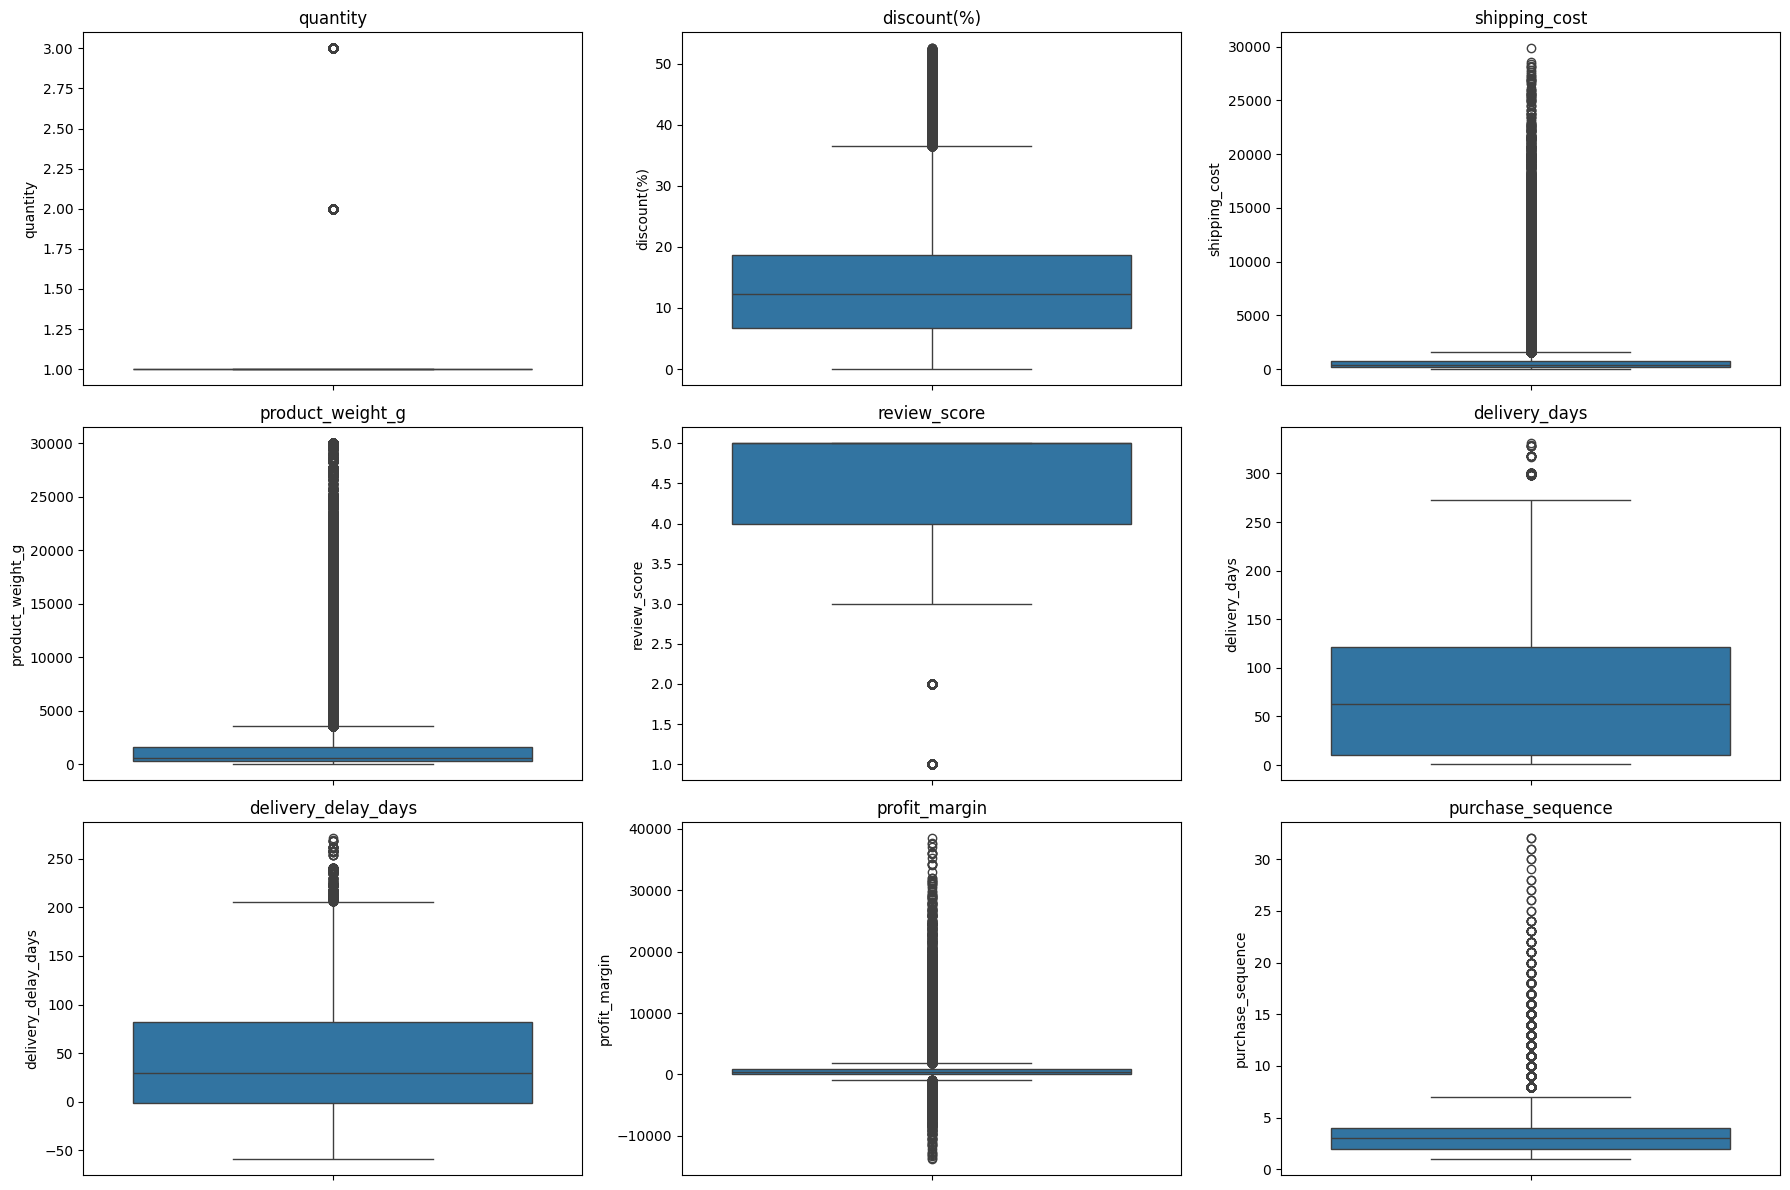

In [6]:
# ============================================
# Boxplots for Outlier Detection
# ============================================

numerical_cols = ['quantity','discount(%)','shipping_cost','product_weight_g','review_score','delivery_days','delivery_delay_days','profit_margin','purchase_sequence']

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(3,3,i)

    sns.boxplot(y=ml_df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [7]:
# ============================================
# IQR Outlier Treatment
# ============================================

for col in numerical_cols:

    Q1 = ml_df[col].quantile(0.25)

    Q3 = ml_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    ml_df[col] = np.where(ml_df[col] < lower_bound, lower_bound, ml_df[col])

    ml_df[col] = np.where(ml_df[col] > upper_bound, upper_bound, ml_df[col])

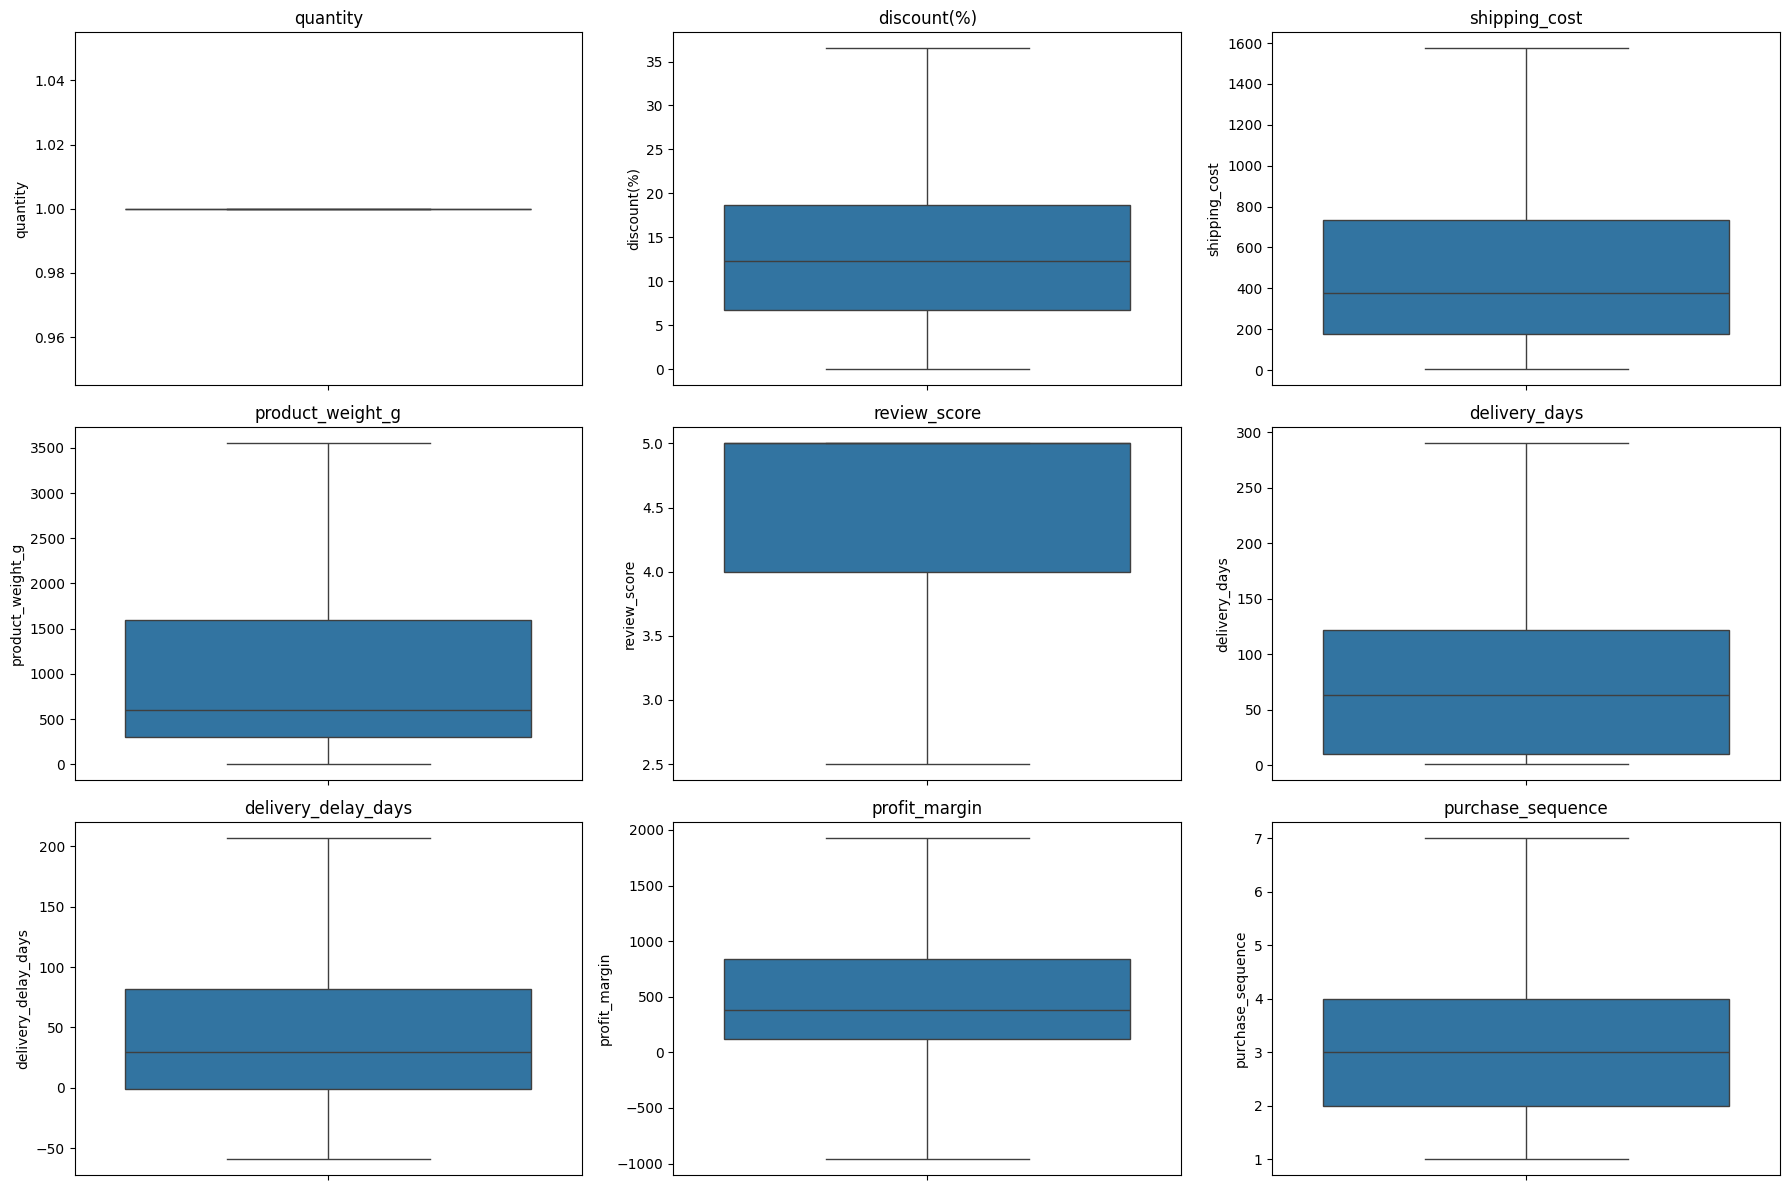

In [8]:
# ============================================
# Rechecking: Boxplots for Outlier Detection
# ============================================

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(3,3,i)

    sns.boxplot(y=ml_df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [9]:
# ============================================
# Linear ML Datset
# ============================================

linear_df = ml_df.copy()
linear_df = linear_df.drop(columns=['customer_id'])

In [13]:
# ============================================
# Scaling Numeircal Columns
# ============================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_col = [
    'discount(%)', 'shipping_cost', 'product_weight_g', 
    'review_score', 'delivery_days', 'delivery_delay_days', 
    'repeat_purchase_flag', 'purchase_sequence'
]
linear_scaler = StandardScaler()
linear_df[num_col] = scaler.fit_transform(linear_df[num_col])

In [14]:
linear_df['quantity'].value_counts()

quantity
1.0    127642
Name: count, dtype: int64

In [15]:
# ============================================
# Label Encoding
# ============================================

from sklearn.preprocessing import LabelEncoder

# Create Label Encoder

le = LabelEncoder()

# Categorical Columns

categorical_cols = ['gender', 'age_group', 'customer_segment', 'payment_type', 'Category_name', 'sub_category_name', 'stock_availability', 'region']

# Apply Label Encoding

for col in categorical_cols:

    linear_df[col] = le.fit_transform(linear_df[col])

linear_df.head()

,gender,age_group,customer_segment,payment_type,quantity,discount(%),shipping_cost,Category_name,sub_category_name,product_weight_g,stock_availability,review_score,region,delivery_days,delivery_delay_days,profit_margin,repeat_purchase_flag,purchase_sequence
1,0,2,2,3,1.0,-0.032901,-0.824827,65,11,2.046485,1,0.756906,4,-0.188399,-0.738338,598.99000,-1.514143,-1.094184
2,0,2,2,3,1.0,-0.308505,-1.105564,28,65,-0.816963,1,0.756906,4,-0.188399,-0.738338,37.98000,-1.514143,-0.575470
3,0,2,2,3,1.0,0.597213,-0.640331,7,24,2.003747,1,0.756906,4,-0.188399,-0.738338,434.22000,-1.514143,-0.056755
4,0,2,2,3,1.0,-0.367971,-0.411827,59,26,-0.577630,1,0.756906,4,-0.188399,-0.738338,1369.23000,-1.514143,0.461959
5,0,3,0,1,1.0,1.577263,2.272801,39,3,-0.475059,1,0.756906,2,-0.105364,0.385684,1923.94375,-1.514143,-1.094184


In [16]:
linear_df.columns

Index(['gender', 'age_group', 'customer_segment', 'payment_type', 'quantity',
       'discount(%)', 'shipping_cost', 'Category_name', 'sub_category_name',
       'product_weight_g', 'stock_availability', 'review_score', 'region',
       'delivery_days', 'delivery_delay_days', 'profit_margin',
       'repeat_purchase_flag', 'purchase_sequence'],
      dtype='object')

# **1st Multiple Linear Regression (MLR)**
### Target: Shipping Cost

In [17]:
# ============================================
# Correlation with Shipping Cost
# ============================================

correlation_sc = linear_df.corr(numeric_only=True)

correlation_sc['shipping_cost'].sort_values(ascending=False)

shipping_cost           1.000000
discount(%)             0.499474
profit_margin           0.370504
product_weight_g        0.078697
region                  0.009341
payment_type            0.002318
gender                  0.001621
repeat_purchase_flag   -0.001096
age_group              -0.001711
stock_availability     -0.002504
review_score           -0.002689
delivery_delay_days    -0.005224
customer_segment       -0.005611
delivery_days          -0.006389
Category_name          -0.058236
sub_category_name      -0.102693
purchase_sequence      -0.139057
quantity                     NaN
Name: shipping_cost, dtype: float64

## Features and Target Variable

In [18]:
# ============================================
# Features and Target Variable
# ============================================
X_sc = linear_df[
    [

        'quantity',
        'discount(%)',
        'sub_category_name',
        'product_weight_g',
        'profit_margin',
        'purchase_sequence'

    ]
]

y_sc = linear_df['shipping_cost']

## Train-Test Split

In [19]:
# ============================================
# Train-Test Split
# ============================================

X_train_sc, X_test_sc, y_train_sc, y_test_sc = train_test_split(X_sc, y_sc, test_size=0.2, random_state=42)

print(X_train_sc.shape)
print(X_test_sc.shape)

(102113, 6)
(25529, 6)


In [20]:
# ============================================
# Build Multiple Linear Regression Model
# ============================================

# Create Model

sc_model = LinearRegression()

# Train Model

sc_model.fit(X_train_sc, y_train_sc)

print("MLR model trained successfully.")

# ============================================
# Prediction on Test Data
# ============================================

y_pred_sc = sc_model.predict(X_test_sc)


MLR model trained successfully.


In [21]:
# ============================================
# Evaluation Metrics
# ============================================

# R² Score

r2_mlr = r2_score(y_test_sc, y_pred_sc)

# MAE

mae_mlr = mean_absolute_error(y_test_sc, y_pred_sc)

# MSE

mse_mlr = mean_squared_error(y_test_sc, y_pred_sc)

# RMSE

rmse_mlr = np.sqrt(mse_mlr)

# Print Results

print("R² Score :", r2_mlr)

print("MAE       :", mae_mlr)

print("MSE       :", mse_mlr)

print("RMSE      :", rmse_mlr)

R² Score : 0.3240701397688218
MAE       : 0.6381639207241969
MSE       : 0.6708637537011914
RMSE      : 0.8190627287950487


The Multiple Linear Regression model achieved moderate predictive performance, indicating that shipping cost may involve non-linear relationships and operational complexity. Therefore, a KNN Regressor model was additionally explored to capture potential non-linear patterns in the data.

# **KNN Regressor for Comparison**

## Build Model

In [22]:
# ============================================
# Build KNN Regressor Model
# ============================================

from sklearn.neighbors import KNeighborsRegressor

# Create Model

knn_regressor = KNeighborsRegressor(n_neighbors=5)

# Train Model

knn_regressor.fit(X_train_sc,y_train_sc)

print("KNN Regressor model trained successfully.")

KNN Regressor model trained successfully.


In [23]:
# ============================================
# Prediction using KNN Regressor
# ============================================

y_pred_knn = knn_regressor.predict(X_test_sc)


In [24]:
# ============================================
# Evaluation Metrics for KNN Regressor
# ============================================

# R² Score

r2_knn = r2_score(y_test_sc,y_pred_knn)

# MAE

mae_knn = mean_absolute_error(y_test_sc,y_pred_knn)

# MSE

mse_knn = mean_squared_error(y_test_sc,y_pred_knn)

# RMSE

rmse_knn = np.sqrt(mse_knn)

# Print Results

print("R² Score :", r2_knn)

print("MAE       :", mae_knn)

print("MSE       :", mse_knn)

print("RMSE      :", rmse_knn)

R² Score : 0.45989387429765394
MAE       : 0.5172584433123002
MSE       : 0.5360580205197009
RMSE      : 0.7321598326319881


# **2nd Linear Regression**
## **Target: Delivery Days**

In [25]:
# ============================================
# Correlation with Delivery Days
# ============================================

correlation_dd = linear_df.corr(numeric_only=True)

correlation_dd['delivery_days'].sort_values(ascending=False)

delivery_days           1.000000
delivery_delay_days     0.913183
payment_type            0.006454
repeat_purchase_flag    0.005786
review_score            0.003885
profit_margin           0.000895
sub_category_name       0.000704
region                 -0.000872
purchase_sequence      -0.001973
gender                 -0.002149
customer_segment       -0.002337
product_weight_g       -0.002788
age_group              -0.002818
Category_name          -0.003637
discount(%)            -0.004450
shipping_cost          -0.006389
stock_availability     -0.006808
quantity                     NaN
Name: delivery_days, dtype: float64

In [26]:
# ============================================
# Features and Target Variable
# ============================================
X_dd = linear_df[
    [
        'discount(%)',
        'stock_availability',
        'product_weight_g',
        'purchase_sequence',
        'shipping_cost',
        'region',
        'profit_margin',
    ]
]

y_dd = linear_df['delivery_days']

In [27]:
# ============================================
# Train-Test Split
# ============================================

X_train_dd, X_test_dd, y_train_dd, y_test_dd = train_test_split(X_dd, y_dd, test_size=0.2, random_state=42)


# ============================================
# Build Multiple Linear Regression Model
# ============================================

model_dd = LinearRegression()

model_dd.fit(X_train_dd, y_train_dd)

print("\nMLR model trained successfully.")

# ============================================
# Prediction
# ============================================

y_pred_dd = model_dd.predict(X_test_dd)

# ============================================
# Evaluation Metrics
# ============================================
r2_dd = r2_score(y_test_dd, y_pred_dd)
mae_dd = mean_absolute_error(y_test_dd, y_pred_dd)
mse_dd = mean_squared_error(y_test_dd, y_pred_dd)
rmse_dd = np.sqrt(mse_dd)

# ============================================
# Print Evaluation Results
# ============================================
print("\nR² Score :", r2_dd)
print("MAE      :", mae_dd)
print("MSE      :", mse_dd)
print("RMSE     :", rmse_dd)


MLR model trained successfully.

R² Score : -0.00012163332098857893
MAE      : 0.8483434043954234
MSE      : 0.9964072025240552
RMSE     : 0.9982019848327568


# **KNN Regressor for Comparison**

## Build Model

In [28]:
# ============================================
# Build KNN Regressor Model
# ============================================

from sklearn.neighbors import KNeighborsRegressor

# Create Model

knn_regressor = KNeighborsRegressor(n_neighbors=5)

# Train Model

knn_regressor.fit(X_train_dd,y_train_dd)

print("KNN Regressor model trained successfully.")

# ============================================
# Prediction using KNN Regressor
# ============================================

y_pred_knn_dd = knn_regressor.predict(X_test_dd)

# ============================================
# Evaluation Metrics for KNN Regressor
# ============================================

# R² Score
r2_knn_dd = r2_score(y_test_dd,y_pred_knn_dd)
# MAE
mae_knn_dd = mean_absolute_error(y_test_dd,y_pred_knn_dd)
# MSE
mse_knn_dd = mean_squared_error(y_test_dd,y_pred_knn_dd)
# RMSE
rmse_knn_dd = np.sqrt(mse_knn_dd)

# Print Results

print("R² Score :", r2_knn_dd)
print("MAE       :", mae_knn_dd)
print("MSE       :", mse_knn_dd)
print("RMSE      :", rmse_knn_dd)

KNN Regressor model trained successfully.
R² Score : -0.1996676638044772
MAE       : 0.9042013678905111
MSE       : 1.1952121232301536
RMSE      : 1.0932575740556996


# **Classification**

In [29]:
# Calssification Dataset
# ==========================

logistic_df = linear_df.copy()

# **1st Logistic Regression**
### Target: High Profit Margin

In [31]:
# Create High Profit Target Variable
profit_threshold = logistic_df['profit_margin'].quantile(0.60)
print(f"60th Percentile Profit Margin Threshold : {profit_threshold:.2f}")

# Create binary target variable
logistic_df['high_profit_flag'] = np.where(logistic_df['profit_margin'] > profit_threshold, 1, 0)

# Check the distribution
print("\nTarget Variable Distribution:")
print(logistic_df['high_profit_flag'].value_counts(normalize=True) * 100)



60th Percentile Profit Margin Threshold : 528.29

Target Variable Distribution:
high_profit_flag
0    60.006894
1    39.993106
Name: proportion, dtype: float64


## Correlation Analysis

In [32]:
# ============================================
# Correlation with Target Variable
# ============================================

# Calculate the full correlation matrix including 'high_profit_flag'
full_correlation_matrix = logistic_df.corr(numeric_only=True)

# Get the correlations of all features with 'high_profit_flag'
correlation_log = full_correlation_matrix['high_profit_flag'].sort_values(ascending=False)

print(correlation_log)

high_profit_flag        1.000000
profit_margin           0.809073
shipping_cost           0.350831
discount(%)             0.235190
sub_category_name       0.015349
payment_type            0.003748
gender                  0.003292
repeat_purchase_flag    0.001034
review_score            0.000323
region                 -0.000306
delivery_delay_days    -0.000386
Category_name          -0.000908
delivery_days          -0.001481
customer_segment       -0.002012
age_group              -0.002601
stock_availability     -0.005808
product_weight_g       -0.017366
purchase_sequence      -0.065621
quantity                     NaN
Name: high_profit_flag, dtype: float64


## Feature Selection for Logistic Regression

In [33]:
# Separate the target variable
y_log = logistic_df['high_profit_flag']

# Select the final features based on correlation and domain knowledge
chosen_features = [
    'customer_segment', 'payment_type', 'quantity', 'discount(%)',
    'shipping_cost', 'Category_name',
    'stock_availability', 'region',
    'delivery_days', 'repeat_purchase_flag'
]

X_log = logistic_df[chosen_features]

print(f"Features DataFrame shape (X): {X_log.shape}")
print(f"Target Series shape (y): {y_log.shape}")

Features DataFrame shape (X): (127642, 10)
Target Series shape (y): (127642,)


## Train-Test Split

In [34]:

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log,y_log,test_size=0.2,random_state=42)

print(X_train_log.shape)
print(X_test_log.shape)

(102113, 10)
(25529, 10)


## Build Logistic Regression Model

In [35]:
# Create Model

log_model = LogisticRegression()

# Train Model

log_model.fit(X_train_log,y_train_log)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Prediction on Test Data

In [36]:
y_pred_log = log_model.predict(X_test_log)

print(y_pred_log[:10])

[0 0 0 0 0 0 1 0 0 1]


## Evaluation Metrics

In [37]:
# Accuracy

accuracy_log = accuracy_score(y_test_log,y_pred_log)

# Precision

precision_log = precision_score(y_test_log,y_pred_log)

# Recall

recall_log = recall_score(y_test_log,y_pred_log)

# F1 Score

f1_log = f1_score(y_test_log,y_pred_log)

# Print Results

print("Accuracy  :", accuracy_log)

print("Precision :", precision_log)

print("Recall    :", recall_log)

print("F1 Score  :", f1_log)

Accuracy  : 0.6753887735516472
Precision : 0.6551897041617918
Recall    : 0.3864353312302839
F1 Score  : 0.48614125379797857


## Confusion Matrix

In [38]:
cm_log = confusion_matrix(y_test_log,y_pred_log)

print(cm_log)

[[13322  2063]
 [ 6224  3920]]


## ROC-AUC CURVE

In [39]:
# Probability Prediction

y_prob_log = log_model.predict_proba(X_test_log)[:,1]

# ROC-AUC Score

auc_score_log = roc_auc_score(y_test_log,y_prob_log)

print("ROC-AUC Score :", auc_score_log)

ROC-AUC Score : 0.7383614431228336


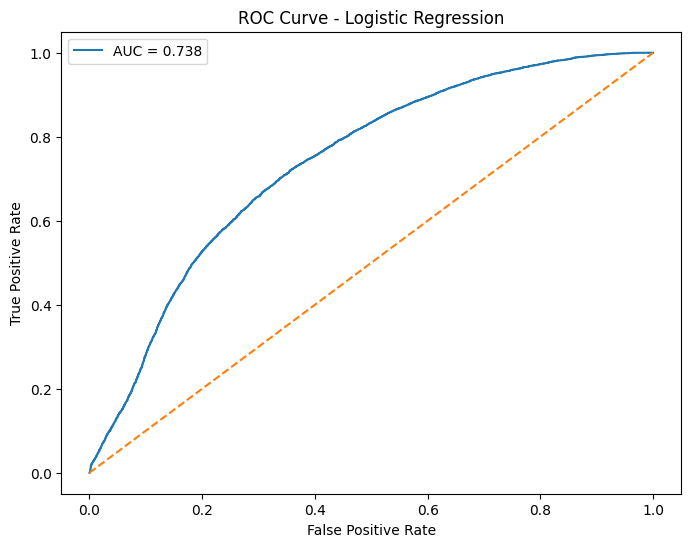

In [40]:
# ============================================
# ROC Curve
# ============================================

# Calculate ROC Curve

fpr, tpr, thresholds = roc_curve(y_test_log,y_prob_log)

# Plot ROC Curve

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,label=f"AUC = {auc_score_log:.3f}")

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# **KNN CLASSIFIER FOR COMPARISON**

In [41]:
# ============================================
# Finding Optimal K Value
# ============================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values_200 = list(range(1, 202, 10))

k_values = []

accuracy_scores = []

# Test K values from 1 to 200

for k in k_values_200:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_log,y_train_log)

    y_pred_k = knn.predict(X_test_log)

    accuracy = accuracy_score(y_test_log,y_pred_k)

    k_values.append(k)

    accuracy_scores.append(accuracy)

# Create DataFrame

k_df = pd.DataFrame({'K Value': k_values,'Accuracy': accuracy_scores})

print(k_df)

    K Value  Accuracy
0         1  0.646480
1        11  0.704728
2        21  0.714952
3        31  0.718751
4        41  0.719809
5        51  0.719731
6        61  0.718712
7        71  0.717929
8        81  0.718947
9        91  0.719300
10      101  0.718516
11      111  0.715892
12      121  0.715539
13      131  0.714247
14      141  0.713737
15      151  0.713620
16      161  0.713385
17      171  0.713228
18      181  0.713424
19      191  0.712131
20      201  0.710799


In [43]:

from sklearn.neighbors import KNeighborsClassifier

# Create Model

knn_classifier = KNeighborsClassifier(n_neighbors=41)

# Train Model

knn_classifier.fit(X_train_log, y_train_log)

# Prediction

y_pred_knn_clf = knn_classifier.predict(X_test_log)

# Evaluation

accuracy_knn = accuracy_score(y_test_log,y_pred_knn_clf)

precision_knn = precision_score(y_test_log,y_pred_knn_clf)

recall_knn = recall_score(y_test_log,y_pred_knn_clf)

f1_knn = f1_score(y_test_log,y_pred_knn_clf)

# Print Results

print("Accuracy  :", accuracy_knn)

print("Precision :", precision_knn)

print("Recall    :", recall_knn)

print("F1 Score  :", f1_knn)

Accuracy  : 0.7198088448431196
Precision : 0.6714826281389749
Recall    : 0.5772870662460567
F1 Score  : 0.6208322289954943


In [44]:
# ============================================
# Confusion Matrix - KNN Classifier
# ============================================

cm_knn = confusion_matrix(y_test_log,y_pred_knn_clf)

print(cm_knn)

[[12520  2865]
 [ 4288  5856]]


# 2nd Classification Model - LOGISTICS
## Target: Repeat Purchase Flag

In [45]:
# ============================================
# Correlation with Target Variable
# ============================================

# Calculate the full correlation matrix including 'high_profit_flag'
full_correlation_matrix = logistic_df.corr(numeric_only=True)

# Get the correlations of all features with 'high_profit_flag'
correlation_log = full_correlation_matrix['repeat_purchase_flag'].sort_values(ascending=False)

print(correlation_log)

repeat_purchase_flag    1.000000
purchase_sequence       0.396809
delivery_delay_days     0.006826
delivery_days           0.005786
Category_name           0.003422
gender                  0.002598
high_profit_flag        0.001034
profit_margin          -0.000573
customer_segment       -0.000682
shipping_cost          -0.001096
product_weight_g       -0.001130
payment_type           -0.001811
discount(%)            -0.002059
sub_category_name      -0.002702
age_group              -0.002803
stock_availability     -0.003394
review_score           -0.004867
region                 -0.069959
quantity                     NaN
Name: repeat_purchase_flag, dtype: float64


In [46]:
ml_df['purchase_sequence'].value_counts()

purchase_sequence
1.0    31725
2.0    28994
3.0    22212
4.0    15220
7.0    12901
5.0    10184
6.0     6406
Name: count, dtype: int64

In [47]:
# Set Target and features
# =================

y_log_rpf = (logistic_df['repeat_purchase_flag'] > 0).astype(int)

best_features = [
    'age_group', 'payment_type', 'discount(%)', 'Category_name', 'region'
]

X_log_rpf = logistic_df[best_features]


# Train-Test Split
# =================
X_train_rpf, X_test_rpf, y_train_rpf, y_test_rpf = train_test_split(X_log_rpf, y_log_rpf, test_size=0.2, random_state=42)

# Build Final Logistic Regression Model
# ======================================
final_model = LogisticRegression(max_iter=500)
final_model.fit(X_train_rpf, y_train_rpf)

print("Final Optimized Logistic Regression Model Trained Successfully!")

# Prediction & Evaluation
# ======================================
y_pred_rpf = final_model.predict(X_test_rpf)

# Accuracy
accuracy_log = accuracy_score(y_test_rpf,y_pred_rpf)
# Precision
precision_log = precision_score(y_test_rpf,y_pred_rpf)
# Recall
recall_log = recall_score(y_test_rpf,y_pred_rpf)
# F1 Score
f1_log = f1_score(y_test_rpf,y_pred_rpf)

# Print Results
print("Accuracy  :", accuracy_log)
print("Precision :", precision_log)
print("Recall    :", recall_log)
print("F1 Score  :", f1_log)

Final Optimized Logistic Regression Model Trained Successfully!
Accuracy  : 0.6929766148301931
Precision : 0.6929766148301931
Recall    : 1.0
F1 Score  : 0.8186487737158723


# KNN Classifier

In [48]:
from sklearn.neighbors import KNeighborsClassifier

# ==============================================================================
# Build KNN Classifier Model (Comparing against Logistic Regression)
# ==============================================================================
# Using K=17 based on your previous tuning visualization for best balance!
model_knn_clf = KNeighborsClassifier(n_neighbors=17)
model_knn_clf.fit(X_train_rpf, y_train_rpf)

print("KNN Classifier Model Trained Successfully using Best Features!")

# Prediction & Evaluation
# ======================================
y_pred_knn_clf = model_knn_clf.predict(X_test_rpf)

# Classification Metrics
accuracy_knn = accuracy_score(y_test_rpf, y_pred_knn_clf)
precision_knn = precision_score(y_test_rpf, y_pred_knn_clf)
recall_knn = recall_score(y_test_rpf, y_pred_knn_clf)
f1_knn = f1_score(y_test_rpf, y_pred_knn_clf)

# Print Results
print("\n--- KNN Classification Results ---")
print("Accuracy  :", accuracy_knn)
print("Precision :", precision_knn)
print("Recall    :", recall_knn)
print("F1 Score  :", f1_knn)

KNN Classifier Model Trained Successfully using Best Features!

--- KNN Classification Results ---
Accuracy  : 0.6768772768224373
Precision : 0.6968231468356542
Recall    : 0.9447741789610536
F1 Score  : 0.802073085874703


# **K-Means Clustering**


## **Cluster 1**


In [49]:
# ============================================
# Create Dataset for Clustering
# ============================================

X_cluster = ml_df[[
    'gender',
    'age_group',
    'payment_type',
    'quantity',
    'discount(%)',
    'shipping_cost',
    'review_score',
    'profit_margin',
    'repeat_purchase_flag',
    'purchase_sequence'
]]

print(X_cluster.shape)

X_cluster.head()

(127642, 10)


,gender,age_group,payment_type,quantity,discount(%),shipping_cost,review_score,profit_margin,repeat_purchase_flag,purchase_sequence
1,Female,36-45,UPI,1.0,13.11,151.01,5.0,598.99000,0,1.0
2,Female,36-45,UPI,1.0,10.70,22.02,5.0,37.98000,0,2.0
3,Female,36-45,UPI,1.0,18.62,235.78,5.0,434.22000,0,3.0
4,Female,36-45,UPI,1.0,10.18,340.77,5.0,1369.23000,0,4.0
5,Female,46-55,Credit Card,1.0,27.19,1574.27,5.0,1923.94375,0,1.0


In [50]:
# Encoding for cat columns:
#===========================

categorical_cols = X_cluster.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    # Fill any missing strings with a placeholder so the encoder doesn't crash
    X_cluster[col] = X_cluster[col].fillna('Unknown')
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))

In [51]:
# ============================================
# Min-Max Scaling for Clustering
# ============================================

from sklearn.preprocessing import MinMaxScaler

# Create Scaler Object

minmax_cluster = MinMaxScaler()

# Scale Features

X_cluster_scaled = minmax_cluster.fit_transform(X_cluster)

print(X_cluster_scaled.shape)

(127642, 10)


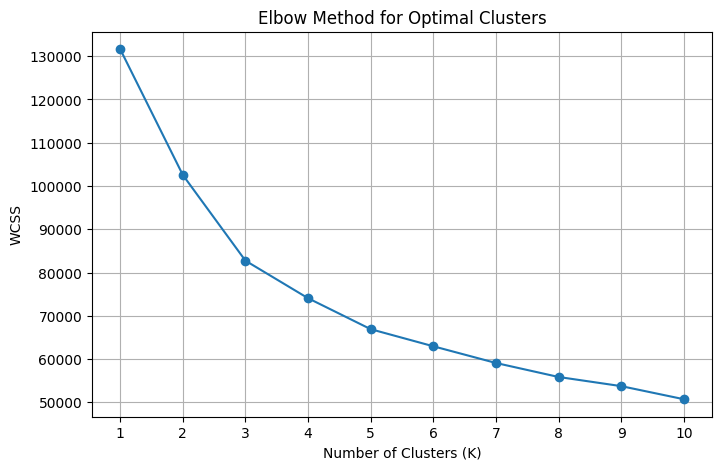

In [52]:
# ============================================
# Elbow Method for Optimal K
# ============================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Test K values from 1 to 10

for k in range(1,11):

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    kmeans.fit(X_cluster_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Method

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.title("Elbow Method for Optimal Clusters")

plt.xticks(range(1,11))

plt.grid(True)

plt.show()

In [53]:
# ============================================
# Silhouette Score Analysis
# ============================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

# Test K values from 2 to 10

for k in range(2,11):

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)

    cluster_labels = kmeans.fit_predict(X_cluster_scaled)

    score = silhouette_score(X_cluster_scaled,cluster_labels)

    silhouette_scores.append(score)

    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.2437
K = 3 | Silhouette Score = 0.2610
K = 4 | Silhouette Score = 0.2849
K = 5 | Silhouette Score = 0.2623
K = 6 | Silhouette Score = 0.2221
K = 7 | Silhouette Score = 0.2441
K = 8 | Silhouette Score = 0.2329
K = 9 | Silhouette Score = 0.2185
K = 10 | Silhouette Score = 0.2287


In [54]:
# ============================================
# Final KMeans Clustering Model
# ============================================

from sklearn.cluster import KMeans

# Final Model with Optimal K

kmeans_final = KMeans(n_clusters=4,random_state=42,n_init=10)

# Fit Model

kmeans_final.fit(X_cluster_scaled)

# Assign Cluster Labels

ml_df['Cluster'] = kmeans_final.labels_

print("Cluster labels assigned successfully.")

Cluster labels assigned successfully.


In [55]:
# ============================================
# Cluster Distribution
# ============================================

print(ml_df['Cluster'].value_counts())

Cluster
0    59082
3    29794
2    25667
1    13099
Name: count, dtype: int64


In [56]:
# ============================================
# Cluster-wise Mean Analysis
# ============================================

cluster_summary = ml_df.groupby('Cluster')[[

    'quantity',
    'shipping_cost',
    'discount(%)',
    'review_score',
    'profit_margin',
    'purchase_sequence'

]].mean().round(2)

print(cluster_summary)

         quantity  shipping_cost  discount(%)  review_score  profit_margin  \
Cluster                                                                      
0             1.0         530.60        13.37          4.28         552.35   
1             1.0         531.59        13.47          4.30         548.90   
2             1.0         530.33        13.40          4.28         554.58   
3             1.0         527.78        13.41          4.27         551.11   

         purchase_sequence  
Cluster                     
0                     3.62  
1                     1.94  
2                     1.96  
3                     3.60  


# **K-Means Clustering with different set of features**

In [57]:
# ============================================
# Clustering Attempt 2
# Refined Feature Selection
# ============================================

X_cluster_v2 = ml_df[[
    
    'discount(%)',
    'review_score',
    'profit_margin',
]]

print(X_cluster_v2.shape)

X_cluster_v2.head()

(127642, 3)


,discount(%),review_score,profit_margin
1,13.11,5.0,598.99000
2,10.70,5.0,37.98000
3,18.62,5.0,434.22000
4,10.18,5.0,1369.23000
5,27.19,5.0,1923.94375


In [58]:
# ============================================
# Min-Max Scaling
# ============================================

from sklearn.preprocessing import MinMaxScaler

minmax_cluster_v2 = MinMaxScaler()

X_cluster_scaled_v2 = minmax_cluster_v2.fit_transform(X_cluster_v2)

print(X_cluster_scaled_v2.shape)

(127642, 3)


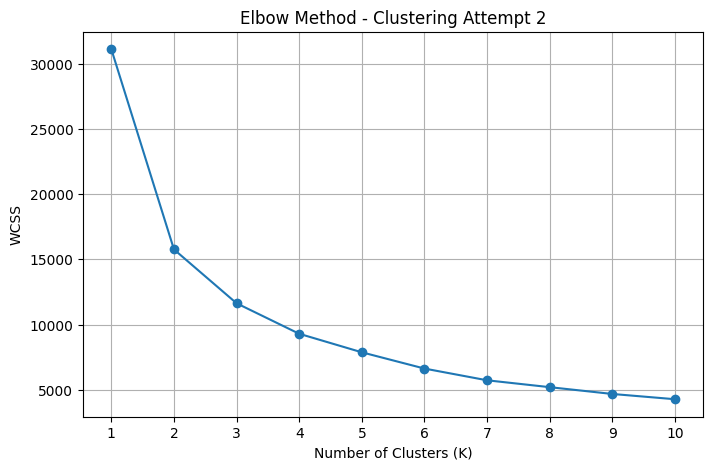

In [59]:
# ============================================
# Elbow Method
# ============================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss_v2 = []

for k in range(1,11):

    kmeans_v2 = KMeans(n_clusters=k,random_state=42,n_init=10)

    kmeans_v2.fit(X_cluster_scaled_v2)

    wcss_v2.append(kmeans_v2.inertia_)

# Plot

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss_v2,marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method - Clustering Attempt 2")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

In [60]:
# ============================================
# Silhouette Score Analysis
# ============================================

from sklearn.metrics import silhouette_score

silhouette_scores_v2 = []

for k in range(2,11):

    kmeans_v2 = KMeans(n_clusters=k,random_state=42,n_init=10)

    cluster_labels_v2 = kmeans_v2.fit_predict(X_cluster_scaled_v2)

    score_v2 = silhouette_score(X_cluster_scaled_v2,cluster_labels_v2)

    silhouette_scores_v2.append(score_v2)

    print(
        f"K = {k} | "
        f"Silhouette Score = "
        f"{score_v2:.4f}"
    )

K = 2 | Silhouette Score = 0.5104
K = 3 | Silhouette Score = 0.3990
K = 4 | Silhouette Score = 0.3956
K = 5 | Silhouette Score = 0.3780
K = 6 | Silhouette Score = 0.3827
K = 7 | Silhouette Score = 0.3891
K = 8 | Silhouette Score = 0.3783
K = 9 | Silhouette Score = 0.3810
K = 10 | Silhouette Score = 0.3767


In [61]:
# ============================================
# Final KMeans Model - Attempt 2
# ============================================

kmeans_final_v2 = KMeans(n_clusters=3
                         ,random_state=42,n_init=10)

kmeans_final_v2.fit(X_cluster_scaled_v2)

# Assign Cluster Labels

ml_df['Cluster_v2'] = kmeans_final_v2.labels_

print(ml_df['Cluster_v2'].value_counts())

Cluster_v2
0    71206
1    29061
2    27375
Name: count, dtype: int64


In [62]:
# ============================================
# Cluster-wise Mean Analysis
# Final Clustering Attempt 2
# ============================================

cluster_summary_v2 = ml_df.groupby('Cluster_v2')[[
    
    'discount(%)',
    'review_score',
    'profit_margin',

]].mean().round(2)

print(cluster_summary_v2)

            discount(%)  review_score  profit_margin
Cluster_v2                                          
0                  9.70          4.75         331.36
1                 13.41          2.68         552.53
2                 23.01          4.75        1126.07


## Evaluating Model Performance

In [63]:
# ============================================
# Clustering Evaluation Metrics
# ============================================

from sklearn.metrics import (silhouette_score,calinski_harabasz_score,davies_bouldin_score)

# ============================================
# Silhouette Score
# Higher is Better
# ============================================

silhouette_avg_v2 = silhouette_score(X_cluster_scaled_v2,ml_df['Cluster_v2'])

print("Silhouette Score :", round(silhouette_avg_v2, 4))

# ============================================
# Calinski-Harabasz Index (CHI)
# Higher is Better
# ============================================

chi_score_v2 = calinski_harabasz_score(X_cluster_scaled_v2,ml_df['Cluster_v2'])

print("Calinski-Harabasz Index :", round(chi_score_v2, 2))

# ============================================
# Davies-Bouldin Index
# Lower is Better
# ============================================

db_score_v2 = davies_bouldin_score(X_cluster_scaled_v2,ml_df['Cluster_v2'])

print("Davies-Bouldin Index :", round(db_score_v2, 4))

Silhouette Score : 0.399
Calinski-Harabasz Index : 106942.46
Davies-Bouldin Index : 1.0779


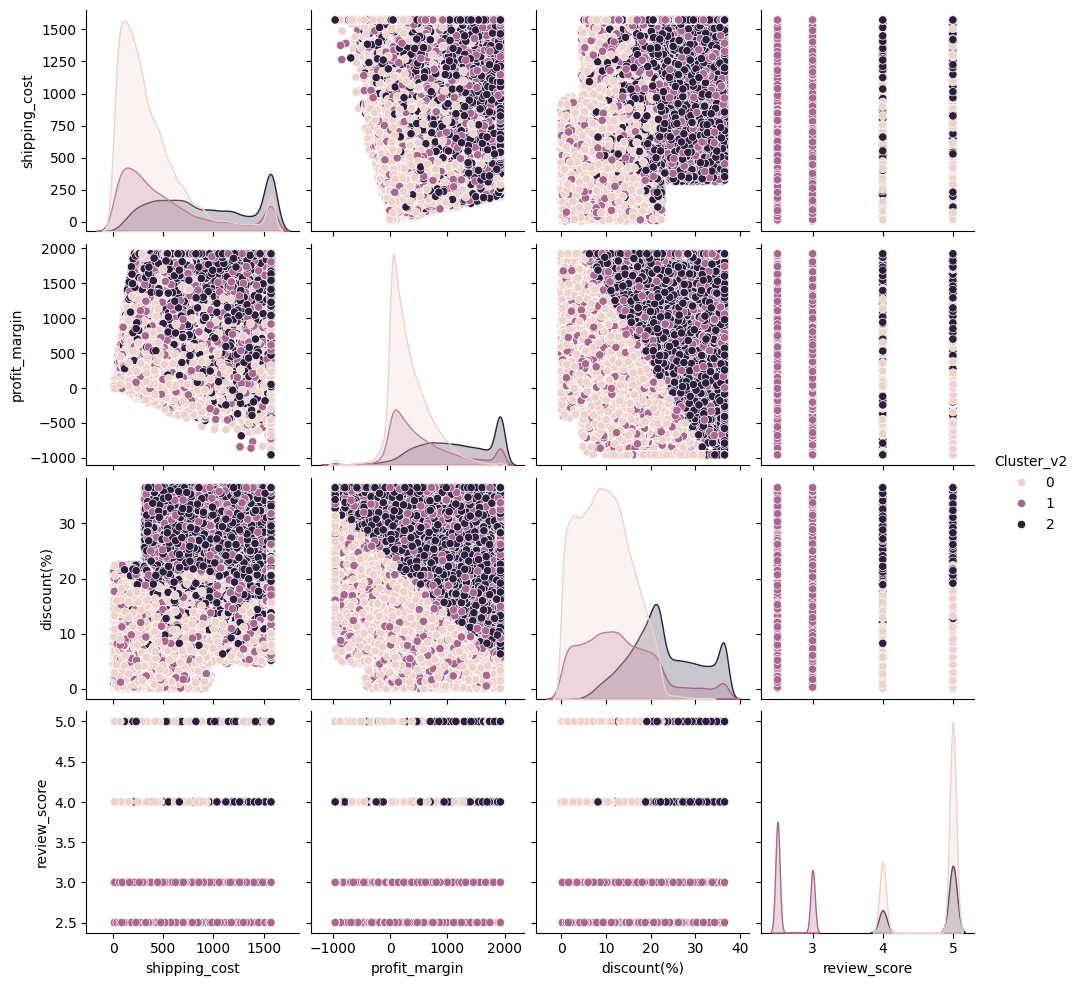

In [64]:
# ============================================
# Pairplot for Cluster Visualization
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

pairplot_features_v2 = ml_df[[
    'shipping_cost',
    'profit_margin',
    'discount(%)',
    'review_score',
    'Cluster_v2'
]]

# Pairplot

sns.pairplot(pairplot_features_v2,hue='Cluster_v2',diag_kind='kde')

plt.show()

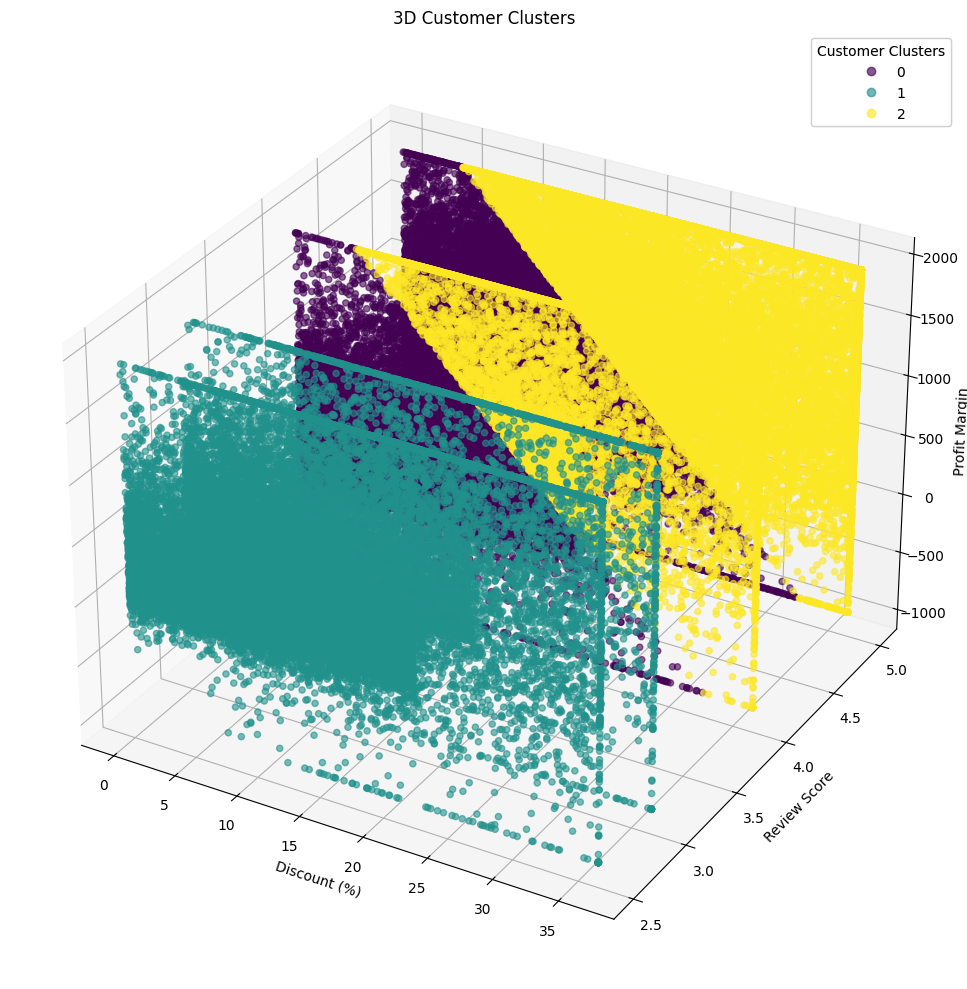

In [65]:
# ============================================
# 3D Scatter Plot for Clusters
# ============================================

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create Figure
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(111, projection='3d')

# Scatter Plot
scatter = ax.scatter(
    ml_df['discount(%)'],
    ml_df['review_score'],
    ml_df['profit_margin'],
    
    c=ml_df['Cluster_v2'],
    cmap='viridis',
    alpha=0.6
)

# Axis Labels
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Review Score')
ax.set_zlabel('Profit Margin')

# Title
ax.set_title('3D Customer Clusters')

# Legend
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Customer Clusters"
)

ax.add_artist(legend1)

plt.tight_layout()
plt.show()

In [66]:
ml_df['Cluster_v2'].value_counts()

Cluster_v2
0    71206
1    29061
2    27375
Name: count, dtype: int64

In [67]:
# on entire dataset - find .describe() for 3 columns
ml_df[['discount(%)', 'review_score', 'profit_margin']].describe()

,discount(%),review_score,profit_margin
count,127642.000000,127642.000000,127642.000000
mean,13.397703,4.277832,552.154595
std,8.744482,0.954109,581.881878
min,0.000000,2.500000,-960.206250
25%,6.720000,4.000000,121.350000
50%,12.250000,5.000000,380.290000
75%,18.630000,5.000000,842.387500
max,36.495000,5.000000,1923.943750


In [68]:
# filter cluster 1 - find the .describe for all the columns
for i in range(3):
    print(f"\nCluster {i}")
    display(
        ml_df[ml_df['Cluster_v2'] == i]
        [['discount(%)', 'review_score', 'profit_margin']]
        .describe()
    )


Cluster 0


,discount(%),review_score,profit_margin
count,71206.000000,71206.000000,71206.000000
mean,9.698921,4.748575,331.362234
std,5.777648,0.433836,368.700098
min,0.000000,4.000000,-960.206250
25%,4.970000,4.000000,76.180000
50%,9.430000,5.000000,243.945000
75%,13.880000,5.000000,518.850000
max,32.580000,5.000000,1923.943750



Cluster 1


,discount(%),review_score,profit_margin
count,29061.000000,29061.000000,29061.000000
mean,13.406163,2.680844,552.526774
std,8.793761,0.240249,582.710925
min,0.000000,2.500000,-960.206250
25%,6.660000,2.500000,121.350000
50%,12.230000,2.500000,379.840000
75%,18.710000,3.000000,841.320000
max,36.495000,3.000000,1923.943750



Cluster 2


,discount(%),review_score,profit_margin
count,27375.000000,27375.000000,27375.000000
mean,23.009743,4.748712,1126.069662
std,7.722928,0.433762,639.148322
min,4.950000,4.000000,-960.206250
25%,17.640000,4.000000,645.375000
50%,21.750000,5.000000,1139.190000
75%,29.040000,5.000000,1756.210000
max,36.495000,5.000000,1923.943750


In [69]:
# filter cluster 2 - find the .describe for all the columns

In [70]:
# filter cluster 3 - find the .describe for all the columns